In [3]:
import kagglehub
import os

os.environ["KAGGLE_USERNAME"] = ""
os.environ["KAGGLE_KEY"] = ""

path = kagglehub.competition_download('competitive-data-science-predict-future-sales')

print("Path to competition files:", path)

Path to competition files: C:\Users\yan1k\.cache\kagglehub\competitions\competitive-data-science-predict-future-sales


D:\Pycharm projects\ecup\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales_train = pd.read_csv(os.path.join(path, 'sales_train.csv'))
items = pd.read_csv(os.path.join(path, 'items.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(path, 'sample_submission.csv'))
item_categories = pd.read_csv(os.path.join(path, 'item_categories.csv'))

In [5]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 50)

sales_train['date'] = pd.to_datetime(sales_train['date'], format='%d.%m.%Y')

sales_train = sales_train.merge(items[['item_id', 'item_category_id']], on='item_id', how='left')

print('sales:', sales_train.shape)
sales_train.head()

sales: (2935849, 7)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id
0,2013-01-02,0,59,22154,999.00,1.0,37
1,2013-01-03,0,25,2552,899.00,1.0,58
2,2013-01-05,0,25,2552,899.00,-1.0,58
3,2013-01-06,0,25,2554,1709.05,1.0,58
4,2013-01-15,0,25,2555,1099.00,1.0,56


In [6]:
for name, df in [('sales', sales_train), ('items', items), ('test', test)]:
    print(f'{name:12s} shape={df.shape}  пропусков={int(df.isnull().sum().sum())}  '
          f'полных дублей={int(df.duplicated().sum())}')

print('\nПериод продаж:', sales_train['date'].min().date(), '—', sales_train['date'].max().date())
print('date_block_num:', sales_train['date_block_num'].min(), '—', sales_train['date_block_num'].max())
print('Уникальных магазинов:', sales_train['shop_id'].nunique(), '\nТоваров:', sales_train['item_id'].nunique(), '\nКатегорий:', sales_train['item_category_id'].nunique())
display(sales_train.dtypes.to_frame('dtype'))

sales        shape=(2935849, 7)  пропусков=0  полных дублей=6
items        shape=(22170, 3)  пропусков=0  полных дублей=0
test         shape=(214200, 3)  пропусков=0  полных дублей=0

Период продаж: 2013-01-01 — 2015-10-31
date_block_num: 0 — 33
Уникальных магазинов: 60 
Товаров: 21807 
Категорий: 84


,dtype
date,datetime64[us]
date_block_num,int64
shop_id,int64
item_id,int64
item_price,float64
item_cnt_day,float64
item_category_id,int64


In [16]:
d = sales_train['item_cnt_day']
print('item_cnt_day: min=%.0f  max=%.0f  среднее=%.3f' % (d.min(), d.max(), d.mean()))
print('Возвратов (item_cnt_day < 0): %d (%.3f%%)' % ((d < 0).sum(), 100 * (d < 0).mean()))
print('Выбросов (item_cnt_day > 20): %d' % (d > 20).sum())

_monthly = (sales_train.groupby(['date_block_num', 'shop_id', 'item_id'], observed=True)
            .agg(item_cnt_month=('item_cnt_day', 'sum'))
            .reset_index())
print('\nСтрок в помесячной таблице:', _monthly.shape[0])
print('item_cnt_month: min=%.0f  max=%.0f' % (_monthly['item_cnt_month'].min(),
                                              _monthly['item_cnt_month'].max()))

_monthly.head()

item_cnt_day: min=-22  max=2169  среднее=1.243
Возвратов (item_cnt_day < 0): 7356 (0.251%)
Выбросов (item_cnt_day > 20): 3414

Строк в помесячной таблице: 1609124
item_cnt_month: min=-22  max=2253


,date_block_num,shop_id,item_id,item_cnt_month
0,0,0,32,6.0
1,0,0,33,3.0
2,0,0,35,1.0
3,0,0,43,1.0
4,0,0,51,2.0


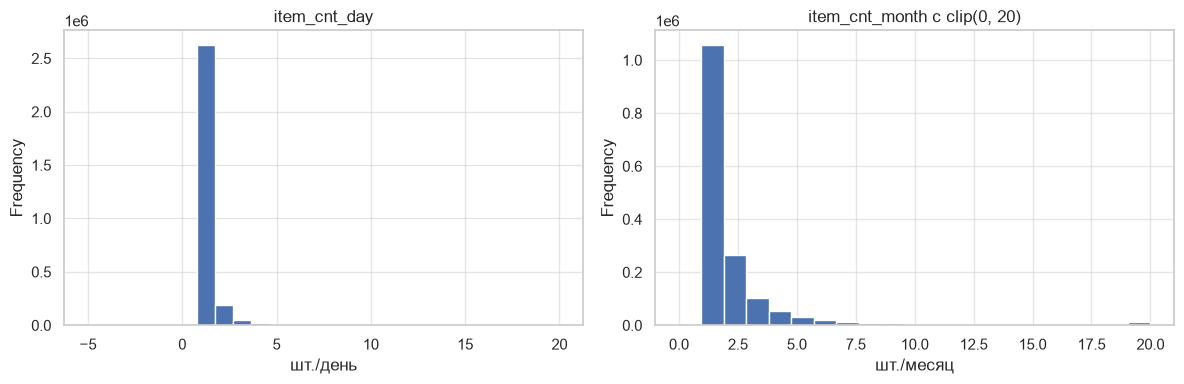

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sales_train.loc[d.between(-5, 20), 'item_cnt_day'].plot(kind='hist', bins=26, ax=ax[0])
ax[0].set_title('item_cnt_day');
ax[0].set_xlabel('шт./день')
_monthly['item_cnt_month'].clip(0, 20).plot(kind='hist', bins=21, ax=ax[1])
ax[1].set_title('item_cnt_month с clip(0, 20)');
ax[1].set_xlabel('шт./месяц')
plt.tight_layout();
plt.show()